In [13]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    Dropout,
    Flatten,
    MaxPooling2D
)
import os
import pandas as pd
import numpy as np
import cv2

In [14]:
from tqdm import tqdm

In [15]:
TRAIN_DIR= 'images/train'
TEST_DIR= 'images/test'

In [16]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label,"completed")
    return image_paths,labels

In [17]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [18]:
print(train)

                                             image     label
0         images/train\angry\Training_10118481.jpg     angry
1         images/train\angry\Training_10120469.jpg     angry
2         images/train\angry\Training_10131352.jpg     angry
3         images/train\angry\Training_10161559.jpg     angry
4          images/train\angry\Training_1021836.jpg     angry
...                                            ...       ...
28704  images/train\surprise\Training_99916297.jpg  surprise
28705  images/train\surprise\Training_99924420.jpg  surprise
28706  images/train\surprise\Training_99937001.jpg  surprise
28707  images/train\surprise\Training_99951755.jpg  surprise
28708  images/train\surprise\Training_99984132.jpg  surprise

[28709 rows x 2 columns]


In [19]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [20]:
print(test)

                                             image     label
0       images/test\angry\PrivateTest_10131363.jpg     angry
1       images/test\angry\PrivateTest_10304478.jpg     angry
2        images/test\angry\PrivateTest_1054527.jpg     angry
3       images/test\angry\PrivateTest_10590091.jpg     angry
4        images/test\angry\PrivateTest_1109992.jpg     angry
...                                            ...       ...
7173  images/test\surprise\PublicTest_98089595.jpg  surprise
7174  images/test\surprise\PublicTest_98567249.jpg  surprise
7175  images/test\surprise\PublicTest_98972870.jpg  surprise
7176  images/test\surprise\PublicTest_99242645.jpg  surprise
7177  images/test\surprise\PublicTest_99446963.jpg  surprise

[7178 rows x 2 columns]


In [21]:
def extract_features(images):
    features = []

    for image in tqdm(images):
        img = load_img(image, color_mode="grayscale", target_size=(48, 48))
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)

    return features

In [22]:
train_features = extract_features(train['image'])

100%|██████████| 28709/28709 [00:47<00:00, 608.31it/s]


In [23]:
test_features = extract_features(test['image'])

100%|██████████| 7178/7178 [00:27<00:00, 261.80it/s]


In [24]:
x_train = train_features/255.0
x_test = test_features/255.0

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [27]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [28]:
y_train = to_categorical(y_train,num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential()

# Input Layer
model.add(Input(shape=(48, 48, 1)))

# First Convolutional Block
model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(7, activation='softmax'))

In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
model.fit(
    x=x_train,
    y=y_train,
    batch_size=256,
    epochs=20,
    validation_data=(x_test, y_test)
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 493s 4s/step - accuracy: 0.2435 - loss: 1.8293 - val_accuracy: 0.2471 - val_loss: 1.8229
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 402s 4s/step - accuracy: 0.2511 - loss: 1.8143 - val_accuracy: 0.2471 - val_loss: 1.8133
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 448s 4s/step - accuracy: 0.2553 - loss: 1.7976 - val_accuracy: 0.2600 - val_loss: 1.7802
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 411s 4s/step - accuracy: 0.2857 - loss: 1.7315 - val_accuracy: 0.3338 - val_loss: 1.6574
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 545s 5s/step - accuracy: 0.4281 - loss: 1.4742 - val_accuracy: 0.4844 - val_loss: 1.3591
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 592s 5s/step - accuracy: 0.4601 - loss: 1.4000 - val_accuracy: 0.5013 - val_loss: 1.2963
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 699s 6s/step - accuracy: 0.4782 - loss: 1.3605 - val_accuracy: 0.4976 - val_loss: 1.2906
Epoch 9/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 572s 5s/step - accuracy: 0.4942 - loss: 1.3220 - val_accu

In [45]:
model_json = model.to_json()
with open("emotionrecogniser.json", "w") as json_file:
    json_file.write(model_json)
model.save_weights("emotionrecogniser.weights.h5")
print("Model Saved Successfully")

Model Saved Successfully


In [46]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [34]:
from tensorflow.keras.preprocessing.image import load_img
import numpy as np

def ef(image):
    img = load_img(image, color_mode="grayscale", target_size=(48, 48))
    feature = np.array(img)
    feature = feature.reshape(1, 48, 48, 1)
    feature = feature / 255.0
    return feature

In [35]:
image = 'images/train/sad/Training_2913.jpg'
print("Original image is sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[np.argmax(pred)]
print("Model Prediction:", pred_label)

Original image is sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Model Prediction: sad


In [36]:
import matplotlib.pyplot as plt
%matplotlib inline

Original image is sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Model Prediction: sad


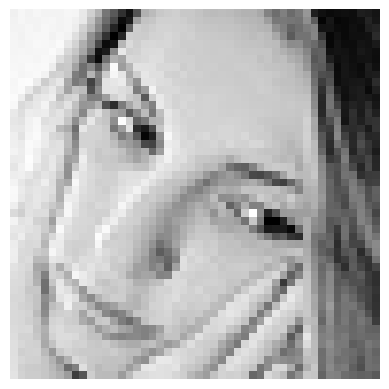

In [37]:
image = 'images/train/sad/Training_396906.jpg'
print("Original image is sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("Model Prediction:", pred_label)
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

Original image is of angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
model prediction is  angry


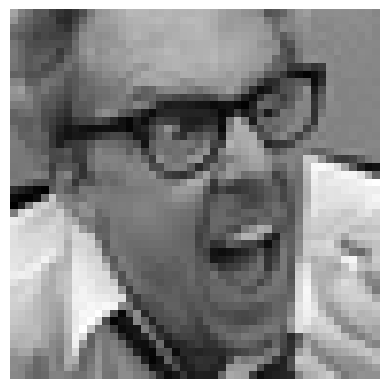

In [38]:
image = 'images/train/angry/Training_3908.jpg'
print("Original image is of angry")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

Original image is of disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
model prediction is  disgust


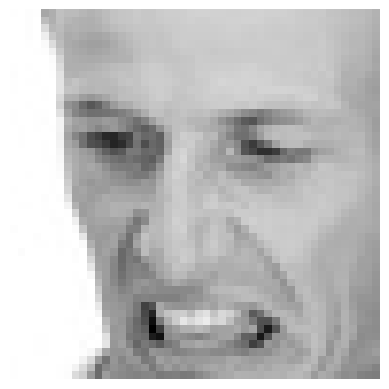

In [39]:
image = 'images/train/disgust/Training_1070239.jpg'
print("Original image is of disgust")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

Original image is of fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
model prediction is  fear


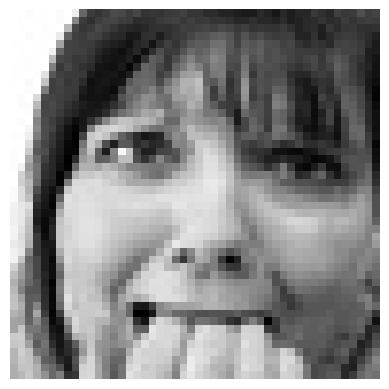

In [40]:
image = 'images/train/fear/Training_266022.jpg'
print("Original image is of fear")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

Original image is of happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
model prediction is  happy


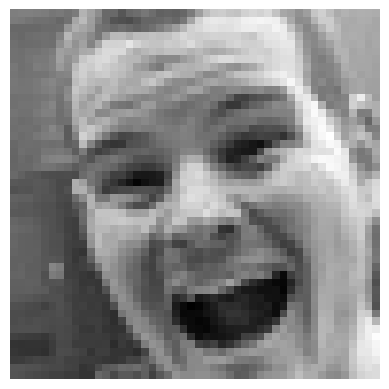

In [41]:
image = 'images/train/happy/Training_11204.jpg'
print("Original image is of happy")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

Original image is of neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
model prediction is  neutral


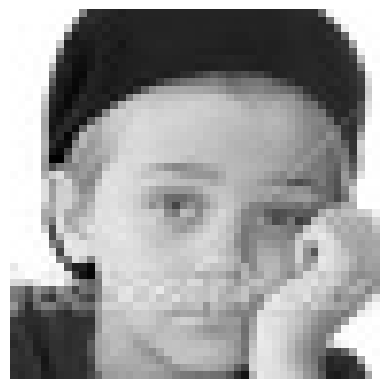

In [42]:
image = 'images/train/neutral/Training_68386.jpg'
print("Original image is of neutral")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

Original image is of surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
model prediction is  surprise


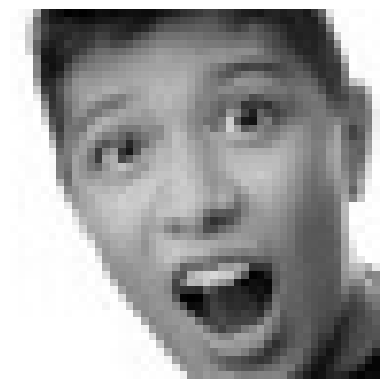

In [43]:
image = 'images/train/surprise/Training_220550.jpg'
print("Original image is of surprise")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()